In [18]:
# ===================================================================
# DIABETES PREDICTION USING DEEP NEURAL NETWORKS (MLP)
# Dataset: BRFSS 2015 - Balanced 50/50 split
# ===================================================================

# 1. INSTALL AND IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Display versions
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.19.0
Pandas version: 2.2.2


In [19]:
# 2. LOAD AND EXPLORE THE DATA



# Load the dataset
df = pd.read_csv('diabetes_dataset.csv')

# Basic exploration
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print("\nTarget variable distribution:")
print(df['Diabetes_binary'].value_counts())
print(f"\nClass balance: {df['Diabetes_binary'].value_counts(normalize=True)}")

print("\nMissing values:")
print(df.isnull().sum())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (70692, 22)

First few rows:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0

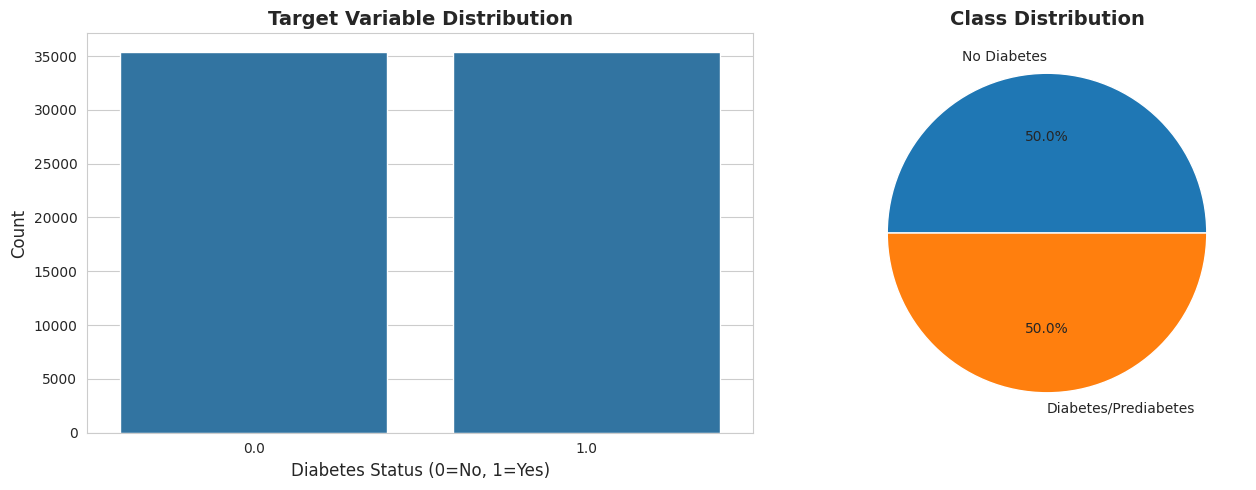

In [20]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)


# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Diabetes_binary', ax=axes[0])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diabetes Status (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Pie chart
df['Diabetes_binary'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                          labels=['No Diabetes', 'Diabetes/Prediabetes'])
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

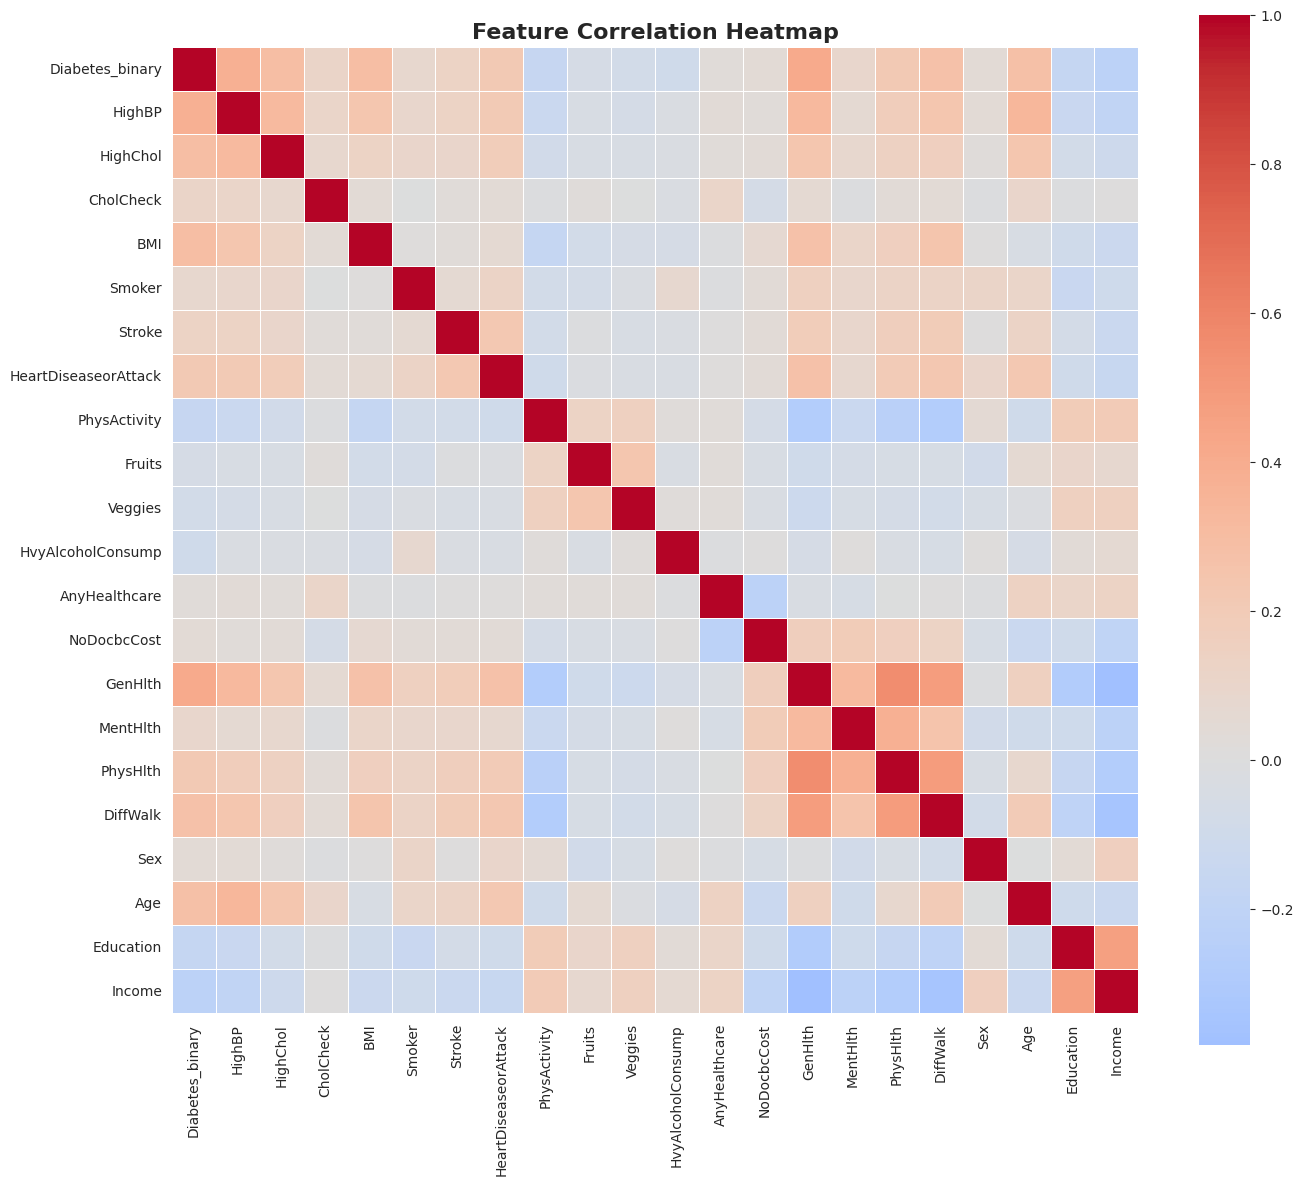


Top 10 features correlated with Diabetes:
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
Name: Diabetes_binary, dtype: float64


In [21]:
# Feature correlation heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = correlation_matrix['Diabetes_binary'].sort_values(ascending=False)
print("\nTop 10 features correlated with Diabetes:")
# Exclude the target itself
print(target_corr[1:11])

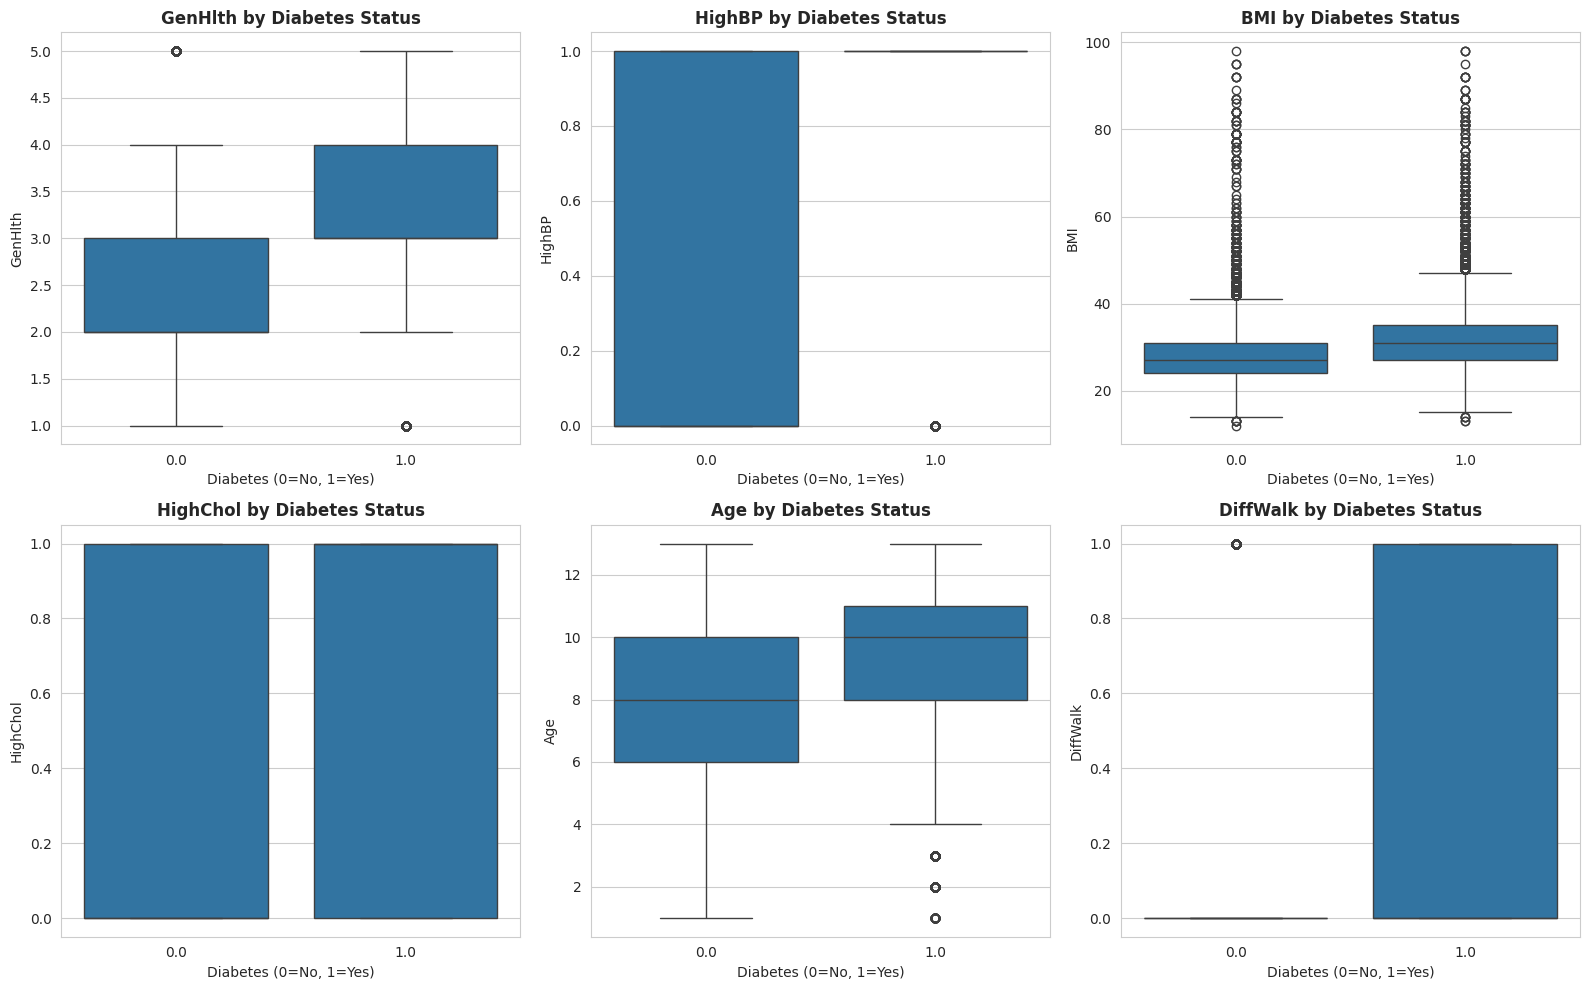

In [22]:
# Distribution of top features by diabetes status
top_features = target_corr[1:7].index.tolist()  # Top 6 features

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    sns.boxplot(data=df, x='Diabetes_binary', y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature} by Diabetes Status', fontweight='bold')
    axes[idx].set_xlabel('Diabetes (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

In [23]:
# 4. DATA PREPROCESSING

# Separate features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

# Split into train, validation, and test sets
# 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15,
                                                    random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176,
                                                    random_state=42, stratify=y_temp)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Verify class distribution in splits
print("\nClass distribution in splits:")
print(f"Train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Val: {y_val.value_counts(normalize=True).to_dict()}")
print(f"Test: {y_test.value_counts(normalize=True).to_dict()}")

Features shape: (70692, 21)
Target shape: (70692,)

Feature columns (21):
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Training set: 49512 samples
Validation set: 10576 samples
Test set: 10604 samples

Class distribution in splits:
Train: {0.0: 0.5, 1.0: 0.5}
Val: {0.0: 0.5, 1.0: 0.5}
Test: {1.0: 0.5, 0.0: 0.5}


In [24]:
# Feature Scaling (Important for Neural Networks!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Data scaling complete!")
print(f"Mean of first feature before scaling: {X_train.iloc[:, 0].mean():.3f}")
print(f"Mean of first feature after scaling: {X_train_scaled[:, 0].mean():.3f}")
print(f"Std of first feature after scaling: {X_train_scaled[:, 0].std():.3f}")

Data scaling complete!
Mean of first feature before scaling: 0.563
Mean of first feature after scaling: 0.000
Std of first feature after scaling: 1.000


Model Architecture:


Model: "Diabetes_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 13,633 (53.25 KB)

 Non-trainable params: 448 (1.75 KB)

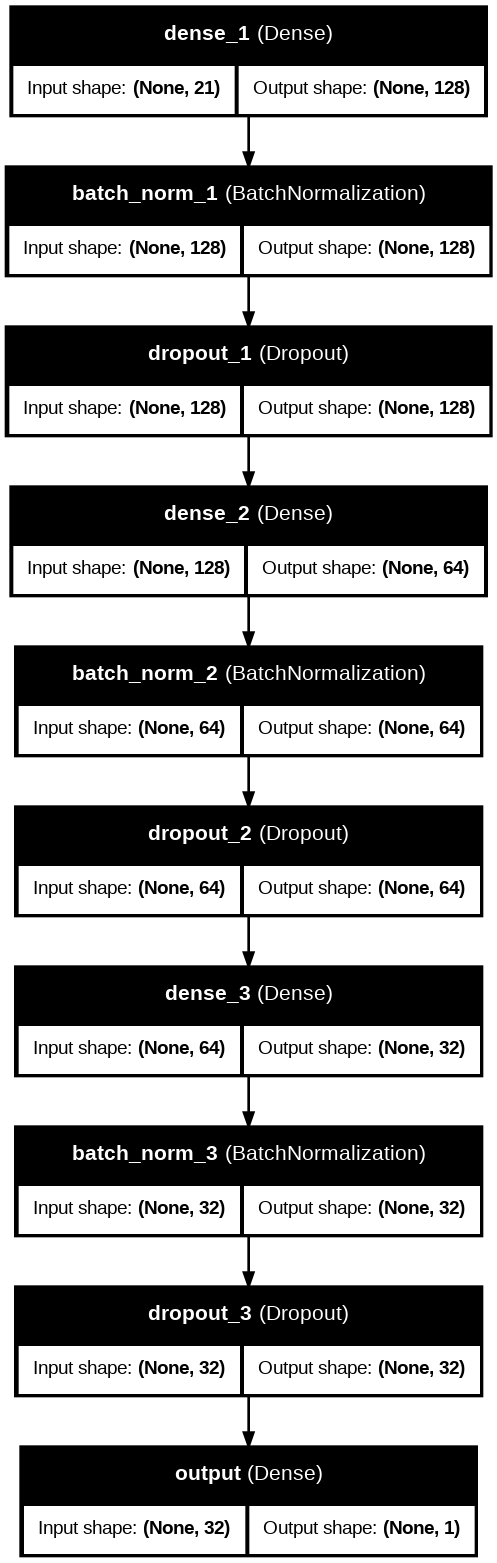

In [25]:
# 5. BUILD DEEP NEURAL NETWORK (MLP) MODEL

def create_mlp_model(input_dim,
                     hidden_layers=[128, 64, 32],
                     dropout_rate=0.3,
                     l2_reg=0.01,
                     learning_rate=0.001):
    """
    Create a Multi-Layer Perceptron (MLP) model for binary classification.

    Parameters:
    -----------
    input_dim : int
        Number of input features
    hidden_layers : list
        List of neurons in each hidden layer
    dropout_rate : float
        Dropout rate for regularization
    l2_reg : float
        L2 regularization strength
    learning_rate : float
        Learning rate for Adam optimizer

    Returns:
    --------
    model : keras.Model
        Compiled Keras model
    """

    model = keras.Sequential(name='Diabetes_MLP')

    # Input layer
    model.add(layers.Input(shape=(input_dim,), name='input'))

    # Hidden layers with BatchNorm, Dropout, and L2 regularization
    for idx, neurons in enumerate(hidden_layers):
        model.add(layers.Dense(
            neurons,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg),
            name=f'dense_{idx+1}'
        ))
        model.add(layers.BatchNormalization(name=f'batch_norm_{idx+1}'))
        model.add(layers.Dropout(dropout_rate, name=f'dropout_{idx+1}'))

    # Output layer
    model.add(layers.Dense(1, activation='sigmoid', name='output'))

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

    return model

# Create the model
input_dim = X_train_scaled.shape[1]
model = create_mlp_model(
    input_dim=input_dim,
    hidden_layers=[128, 64, 32],
    dropout_rate=0.3,
    l2_reg=0.01,
    learning_rate=0.001
)

# Display model architecture
print("Model Architecture:")
model.summary()

# Visualize model architecture
keras.utils.plot_model(model, to_file='model_architecture.png',
                       show_shapes=True, show_layer_names=True, dpi=96)

In [26]:
# 6. TRAIN THE MODEL

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_diabetes_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

# Train the model
print("\nTraining the model...\n")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")


Training the model...

Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6728 - auc: 0.7305 - loss: 2.0048 - precision: 0.6651 - recall: 0.6890
Epoch 1: val_auc improved from None to 0.82177, saving model to best_diabetes_model.h5



Epoch 1: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7022 - auc: 0.7658 - loss: 1.6830 - precision: 0.6899 - recall: 0.7347 - val_accuracy: 0.7248 - val_auc: 0.8218 - val_loss: 1.1846 - val_precision: 0.6599 - val_recall: 0.9276 - learning_rate: 0.0010
Epoch 2/100
184/194 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7308 - auc: 0.7995 - loss: 1.0351 - precision: 0.7055 - recall: 0.7890
Epoch 2: val_auc improved from 0.82177 to 0.82511, saving model to best_diabetes_model.h5



Epoch 2: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7356 - auc: 0.8046 - loss: 0.9139 - precision: 0.7109 - recall: 0.7940 - val_accuracy: 0.7305 - val_auc: 0.8251 - val_loss: 0.7591 - val_precision: 0.6687 - val_recall: 0.9138 - learning_rate: 0.0010
Epoch 3/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7453 - auc: 0.8152 - loss: 0.6806 - precision: 0.7193 - recall: 0.8019
Epoch 3: val_auc improved from 0.82511 to 0.82699, saving model to best_diabetes_model.h5



Epoch 3: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7442 - auc: 0.8152 - loss: 0.6468 - precision: 0.7200 - recall: 0.7993 - val_accuracy: 0.7408 - val_auc: 0.8270 - val_loss: 0.6101 - val_precision: 0.6855 - val_recall: 0.8901 - learning_rate: 0.0010
Epoch 4/100
177/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7477 - auc: 0.8214 - loss: 0.5703 - precision: 0.7215 - recall: 0.8038
Epoch 4: val_auc improved from 0.82699 to 0.82785, saving model to best_diabetes_model.h5



Epoch 4: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7470 - auc: 0.8207 - loss: 0.5608 - precision: 0.7232 - recall: 0.8004 - val_accuracy: 0.7489 - val_auc: 0.8279 - val_loss: 0.5507 - val_precision: 0.7043 - val_recall: 0.8580 - learning_rate: 0.0010
Epoch 5/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7478 - auc: 0.8215 - loss: 0.5387 - precision: 0.7241 - recall: 0.7979
Epoch 5: val_auc improved from 0.82785 to 0.82791, saving model to best_diabetes_model.h5


...


Epoch 35: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7525 - auc: 0.8289 - loss: 0.5105 - precision: 0.7298 - recall: 0.8018 - val_accuracy: 0.7538 - val_auc: 0.8300 - val_loss: 0.5078 - val_precision: 0.7289 - val_recall: 0.8081 - learning_rate: 2.5000e-04
Epoch 36/100
180/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7555 - auc: 0.8296 - loss: 0.5090 - precision: 0.7304 - recall: 0.8070
Epoch 36: val_auc did not improve from 0.82998
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7535 - auc: 0.8289 - loss: 0.5100 - precision: 0.7302 - recall: 0.8040 - val_accuracy: 0.7526 - val_auc: 0.8296 - val_loss: 0.5081 - val_precision: 0.7249 - val_recall: 0.8143 - learning_rate: 2.5000e-04
Epoch 37/100
178/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7548 - auc: 0.8302 - loss: 0.5083 - precision: 0.7303 - recall: 0.8051
Epoch 37: val_auc did not improve from 0.82998
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy


Epoch 42: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7544 - auc: 0.8305 - loss: 0.5073 - precision: 0.7323 - recall: 0.8017 - val_accuracy: 0.7545 - val_auc: 0.8301 - val_loss: 0.5074 - val_precision: 0.7286 - val_recall: 0.8113 - learning_rate: 1.2500e-04
Epoch 43/100
181/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7566 - auc: 0.8322 - loss: 0.5046 - precision: 0.7324 - recall: 0.8060
Epoch 43: val_auc did not improve from 0.83005
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7551 - auc: 0.8310 - loss: 0.5064 - precision: 0.7333 - recall: 0.8016 - val_accuracy: 0.7536 - val_auc: 0.8296 - val_loss: 0.5076 - val_precision: 0.7283 - val_recall: 0.8090 - learning_rate: 1.2500e-04
Epoch 44/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7555 - auc: 0.8319 - loss: 0.5056 - precision: 0.7323 - recall: 0.8030
Epoch 44: val_auc did not improve from 0.83005
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy


Epoch 50: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7558 - auc: 0.8314 - loss: 0.5056 - precision: 0.7341 - recall: 0.8019 - val_accuracy: 0.7527 - val_auc: 0.8301 - val_loss: 0.5062 - val_precision: 0.7277 - val_recall: 0.8077 - learning_rate: 1.2500e-04
Epoch 51/100
186/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7567 - auc: 0.8323 - loss: 0.5043 - precision: 0.7323 - recall: 0.8064
Epoch 51: val_auc did not improve from 0.83006
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7559 - auc: 0.8317 - loss: 0.5054 - precision: 0.7341 - recall: 0.8024 - val_accuracy: 0.7529 - val_auc: 0.8297 - val_loss: 0.5065 - val_precision: 0.7267 - val_recall: 0.8107 - learning_rate: 1.2500e-04
Epoch 52/100
181/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7571 - auc: 0.8327 - loss: 0.5038 - precision: 0.7343 - recall: 0.8031
Epoch 52: val_auc did not improve from 0.83006
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy


Epoch 56: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7575 - auc: 0.8330 - loss: 0.5028 - precision: 0.7360 - recall: 0.8032 - val_accuracy: 0.7554 - val_auc: 0.8301 - val_loss: 0.5059 - val_precision: 0.7312 - val_recall: 0.8077 - learning_rate: 6.2500e-05
Epoch 57/100
178/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7585 - auc: 0.8341 - loss: 0.5017 - precision: 0.7338 - recall: 0.8086
Epoch 57: val_auc did not improve from 0.83011
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7575 - auc: 0.8332 - loss: 0.5031 - precision: 0.7359 - recall: 0.8035 - val_accuracy: 0.7536 - val_auc: 0.8299 - val_loss: 0.5059 - val_precision: 0.7310 - val_recall: 0.8024 - learning_rate: 6.2500e-05
Epoch 58/100
184/194 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7572 - auc: 0.8341 - loss: 0.5019 - precision: 0.7330 - recall: 0.8063
Epoch 58: val_auc did not improve from 0.83011
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy


Epoch 62: finished saving model to best_diabetes_model.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7585 - auc: 0.8339 - loss: 0.5021 - precision: 0.7370 - recall: 0.8037 - val_accuracy: 0.7537 - val_auc: 0.8303 - val_loss: 0.5053 - val_precision: 0.7315 - val_recall: 0.8016 - learning_rate: 3.1250e-05
Epoch 63/100
188/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7582 - auc: 0.8354 - loss: 0.5000 - precision: 0.7341 - recall: 0.8071
Epoch 63: val_auc did not improve from 0.83028
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7568 - auc: 0.8342 - loss: 0.5017 - precision: 0.7360 - recall: 0.8009 - val_accuracy: 0.7537 - val_auc: 0.8302 - val_loss: 0.5053 - val_precision: 0.7328 - val_recall: 0.7986 - learning_rate: 3.1250e-05
Epoch 64/100
184/194 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7578 - auc: 0.8361 - loss: 0.4990 - precision: 0.7353 - recall: 0.8029
Epoch 64: val_auc did not improve from 0.83028
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy

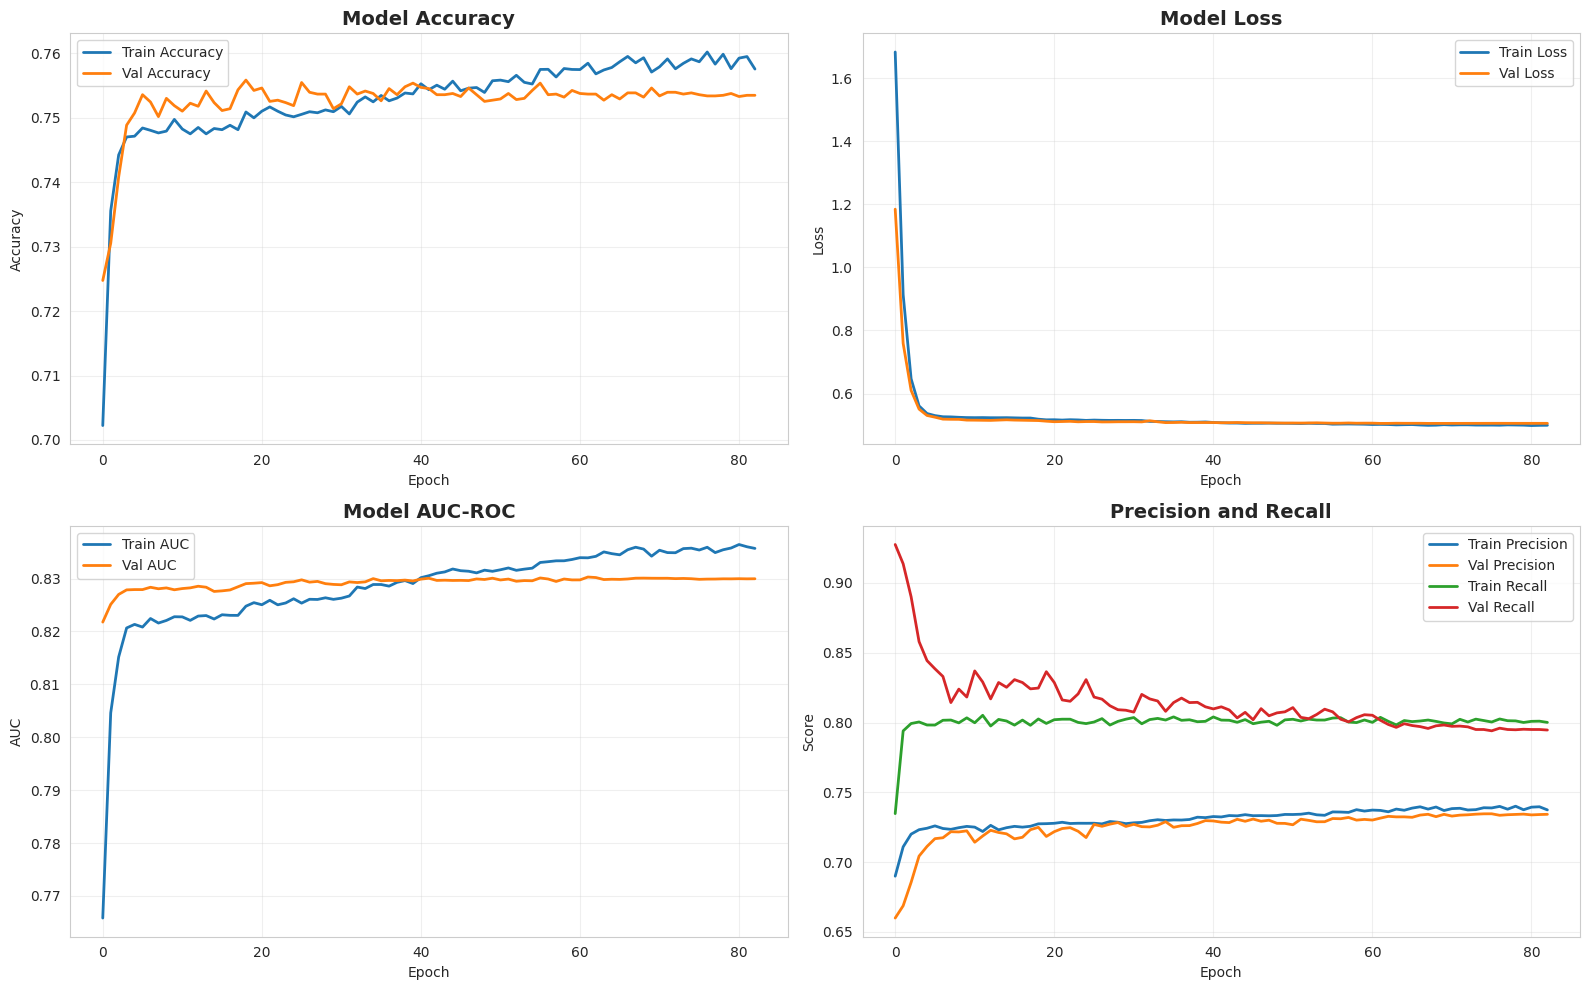

In [27]:
# 7. VISUALIZE TRAINING HISTORY


def plot_training_history(history):
    """Plot training and validation metrics over epochs."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # AUC
    axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1, 0].set_title('Model AUC-ROC', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Precision and Recall
    axes[1, 1].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 1].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    axes[1, 1].set_title('Precision and Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [28]:
# 8. EVALUATE THE MODEL

# Load best model
model = keras.models.load_model('best_diabetes_model.h5')

# Make predictions on test set
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("="*60)
print("MODEL PERFORMANCE ON TEST SET")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
print("="*60)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['No Diabetes', 'Diabetes/Prediabetes']))

332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MODEL PERFORMANCE ON TEST SET
Accuracy:  0.7543
Precision: 0.7305
Recall:    0.8061
F1-Score:  0.7664
AUC-ROC:   0.8323

Classification Report:
                      precision    recall  f1-score   support

         No Diabetes       0.78      0.70      0.74      5302
Diabetes/Prediabetes       0.73      0.81      0.77      5302

            accuracy                           0.75     10604
           macro avg       0.76      0.75      0.75     10604
        weighted avg       0.76      0.75      0.75     10604



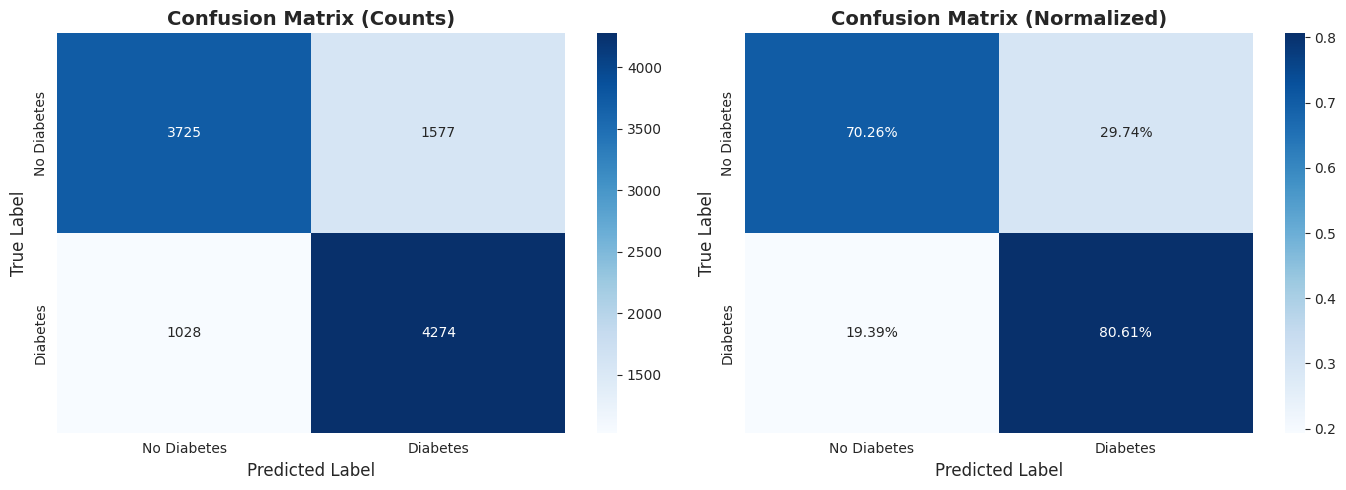


True Negatives:  3725
False Positives: 1577
False Negatives: 1028
True Positives:  4274

Specificity: 0.7026
Sensitivity (Recall): 0.8061


In [29]:
# 9. CONFUSION MATRIX VISUALIZATION


cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Normalized
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# Calculate specific metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nSpecificity: {tn/(tn+fp):.4f}")
print(f"Sensitivity (Recall): {tp/(tp+fn):.4f}")

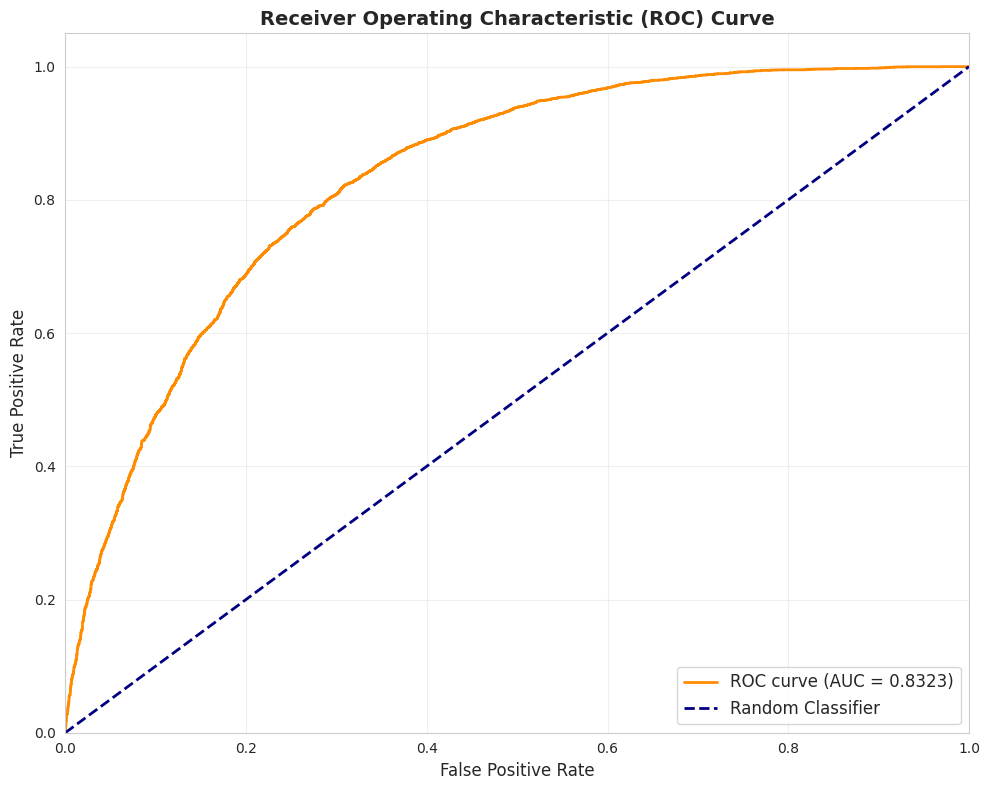

In [30]:
# 10. ROC CURVE
# ===================================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Calculating feature importance using gradient-based method...
Computing gradients for 500 samples...
✓ Gradients calculated!

Top 10 Most Important Features:
                 feature  importance
13               GenHlth    0.107858
3                    BMI    0.100976
18                   Age    0.065296
0                 HighBP    0.055635
1               HighChol    0.048867
20                Income    0.033168
6   HeartDiseaseorAttack    0.030827
17                   Sex    0.030182
2              CholCheck    0.023582
5                 Stroke    0.023265


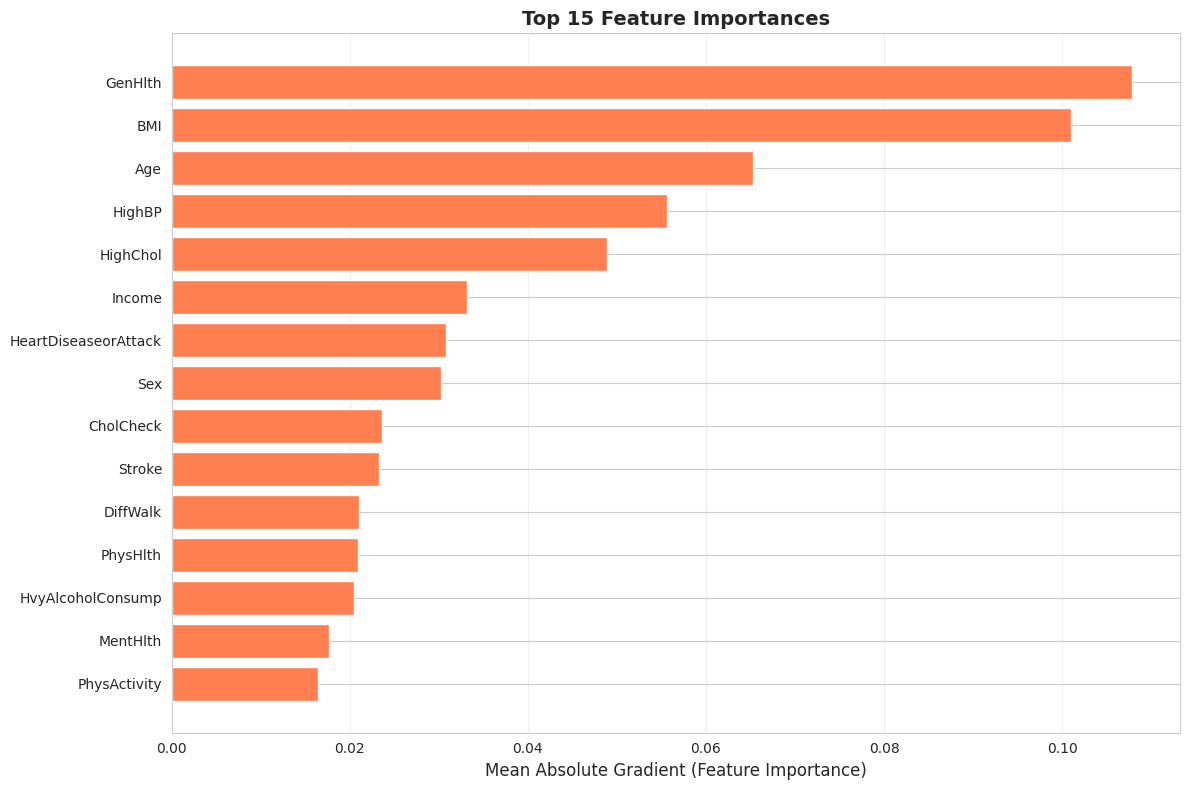

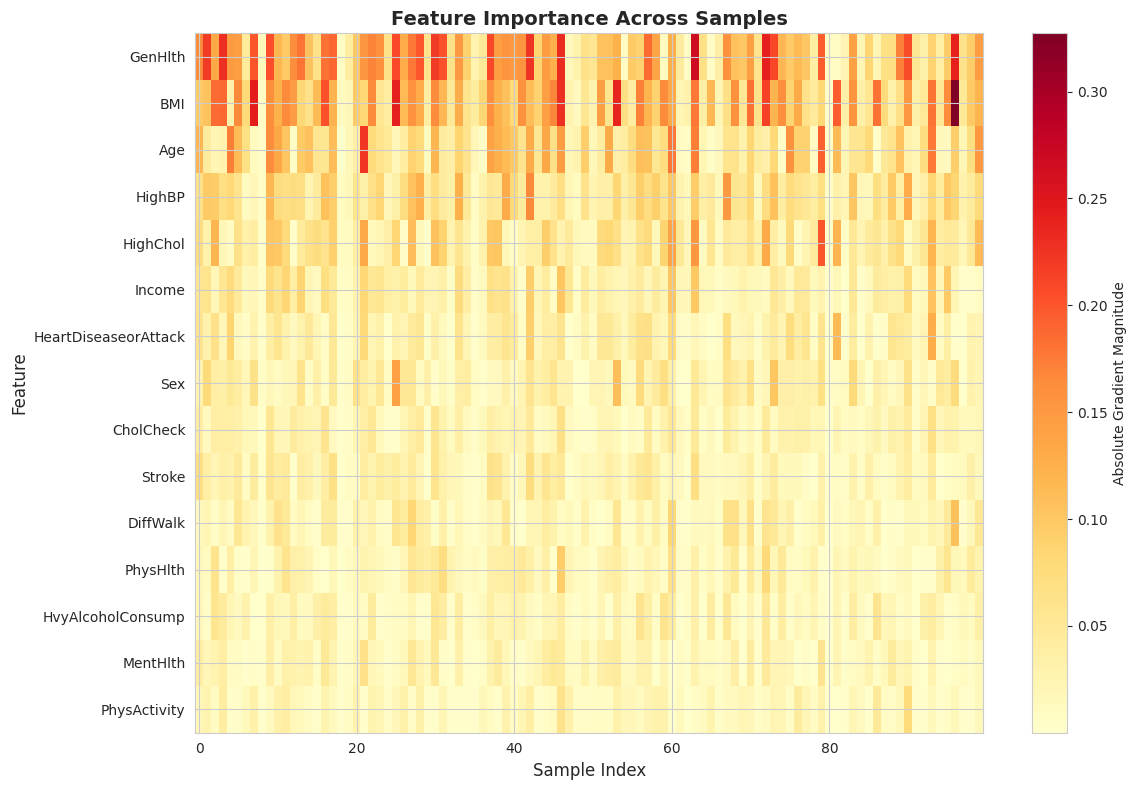

✓ Feature importance analysis complete!


In [36]:
# 11. FEATURE IMPORTANCE - SIMPLE GRADIENT-BASED METHOD (NO SHAP)
# ===================================================================

print("Calculating feature importance using gradient-based method...")

import tensorflow as tf

# Get feature names
feature_names = X.columns.tolist()

# Use a sample from validation set
sample_size = 500
X_sample = X_val_scaled[:sample_size]

print(f"Computing gradients for {sample_size} samples...")

# Calculate gradients
X_tensor = tf.convert_to_tensor(X_sample, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(X_tensor)
    predictions = model(X_tensor)

# Get gradients
gradients = tape.gradient(predictions, X_tensor)

# Convert to numpy
gradients_np = gradients.numpy()

# Calculate feature importance as mean absolute gradient
feature_importance = np.abs(gradients_np).mean(axis=0)

print("✓ Gradients calculated!")

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

# Visualize
plt.figure(figsize=(12, 8))
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.barh(range(top_n), top_features['importance'], align='center', color='coral')
plt.yticks(range(top_n), top_features['feature'])
plt.xlabel('Mean Absolute Gradient (Feature Importance)', fontsize=12)
plt.title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Additional visualization: Feature importance with individual sample contributions
plt.figure(figsize=(12, 8))

# Get top 15 features
top_15_indices = feature_importance_df.head(15).index

# Create a heatmap-like visualization
sample_gradients = np.abs(gradients_np[:100, :])  # Use first 100 samples
top_15_gradients = sample_gradients[:, [X.columns.tolist().index(feat) for feat in feature_importance_df.head(15)['feature']]]

plt.imshow(top_15_gradients.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(label='Absolute Gradient Magnitude')
plt.yticks(range(15), feature_importance_df.head(15)['feature'])
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance Across Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Feature importance analysis complete!")

Calculating SHAP values with optimized settings...
Computing SHAP for 100 samples with 50 background samples...
Expected time: ~30-60 seconds


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(100, 21))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(50, 21))']
  warnings.warn(msg)


✓ SHAP computed in 1.1 seconds!
SHAP values shape: (100, 21)

Top 10 Most Important Features (SHAP):
                 feature  importance
13               GenHlth    0.103067
3                    BMI    0.084728
18                   Age    0.079878
0                 HighBP    0.058461
1               HighChol    0.050356
20                Income    0.024850
17                   Sex    0.021899
6   HeartDiseaseorAttack    0.011226
19             Education    0.010301
16              DiffWalk    0.009161


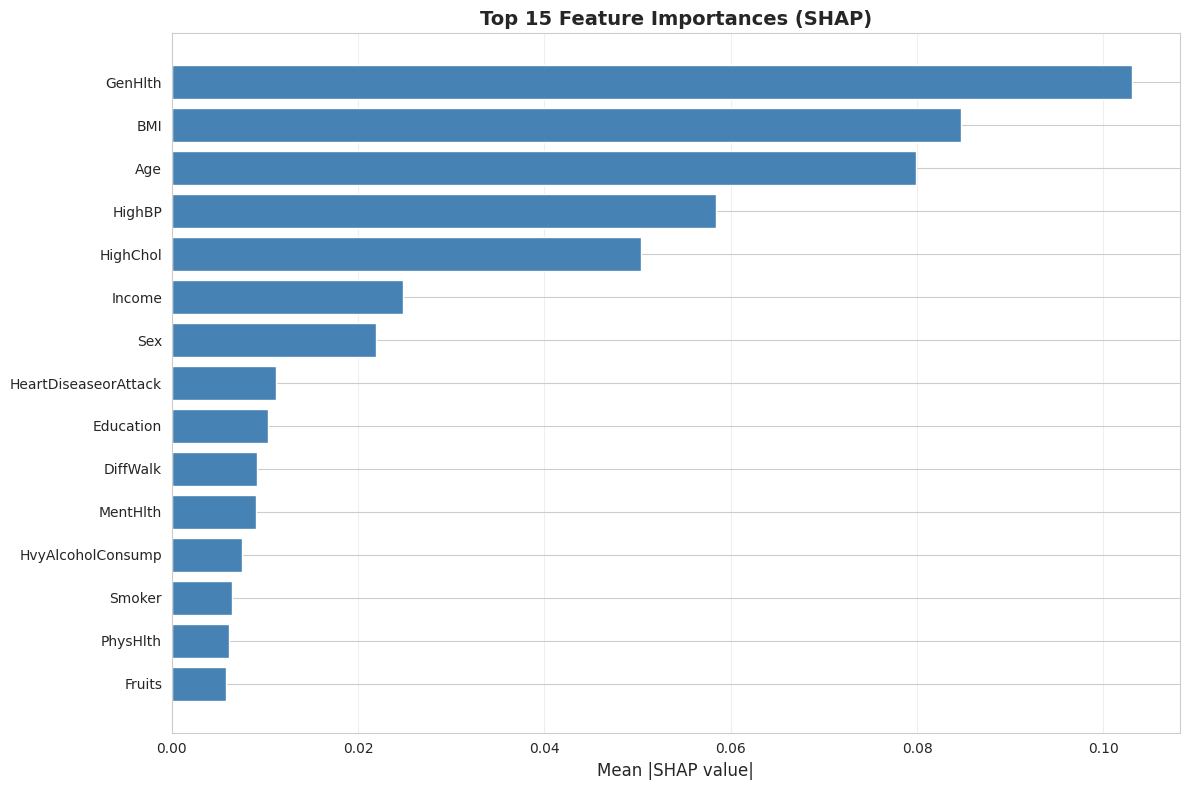

/tmp/ipykernel_4336/1578036016.py:76: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array, X_sample, feature_names=feature_names, show=False)


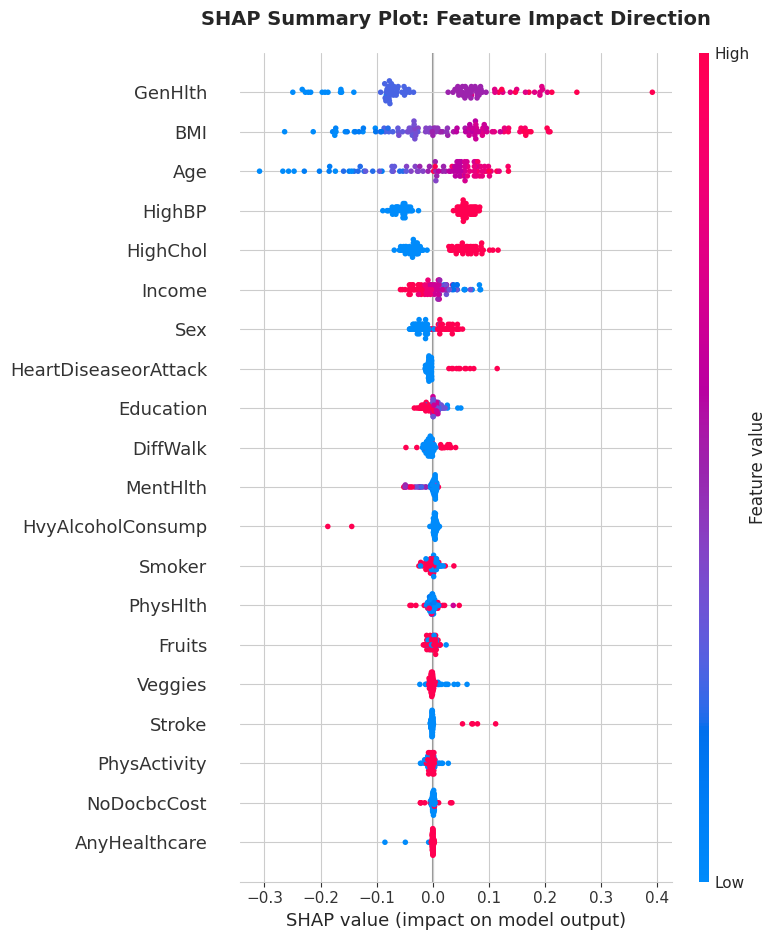

✓ SHAP analysis complete!


In [40]:
# 11. FEATURE IMPORTANCE - OPTIMIZED SHAP (MUCH FASTER)
# ===================================================================

!pip install shap -q

import shap
import time

print("Calculating SHAP values with optimized settings...")

# OPTIMIZATION 1: Use only 100 samples (still representative)
sample_size = 100  # Reduced from 500-1000
X_sample = X_val_scaled[:sample_size]

# OPTIMIZATION 2: Use only 50 background samples
background_size = 50  # Reduced from 100
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], background_size, replace=False)]

# Get feature names
feature_names = X.columns.tolist()

print(f"Computing SHAP for {sample_size} samples with {background_size} background samples...")
print("Expected time: ~30-60 seconds")

start_time = time.time()

# GradientExplainer - still fastest option
explainer = shap.GradientExplainer(model, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Fix shape issues
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values

# Handle 3D output: (n_samples, n_features, 1) -> (n_samples, n_features)
if shap_values_array.ndim == 3:
    shap_values_array = shap_values_array.squeeze(axis=-1)  # Remove last dimension

elapsed_time = time.time() - start_time
print(f"✓ SHAP computed in {elapsed_time:.1f} seconds!")

print(f"SHAP values shape: {shap_values_array.shape}")

# Calculate feature importance
shap_importance = np.abs(shap_values_array).mean(axis=0)

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (SHAP):")
print(feature_importance_df.head(10))

# Bar plot
plt.figure(figsize=(12, 8))
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.barh(range(top_n), top_features['importance'], align='center', color='steelblue')
plt.yticks(range(top_n), top_features['feature'])
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.title(f'Top {top_n} Feature Importances (SHAP)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# SHAP Summary Plot (THIS IS THE KEY PLOT FOR YOUR REPORT)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_array, X_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot: Feature Impact Direction',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP analysis complete!")

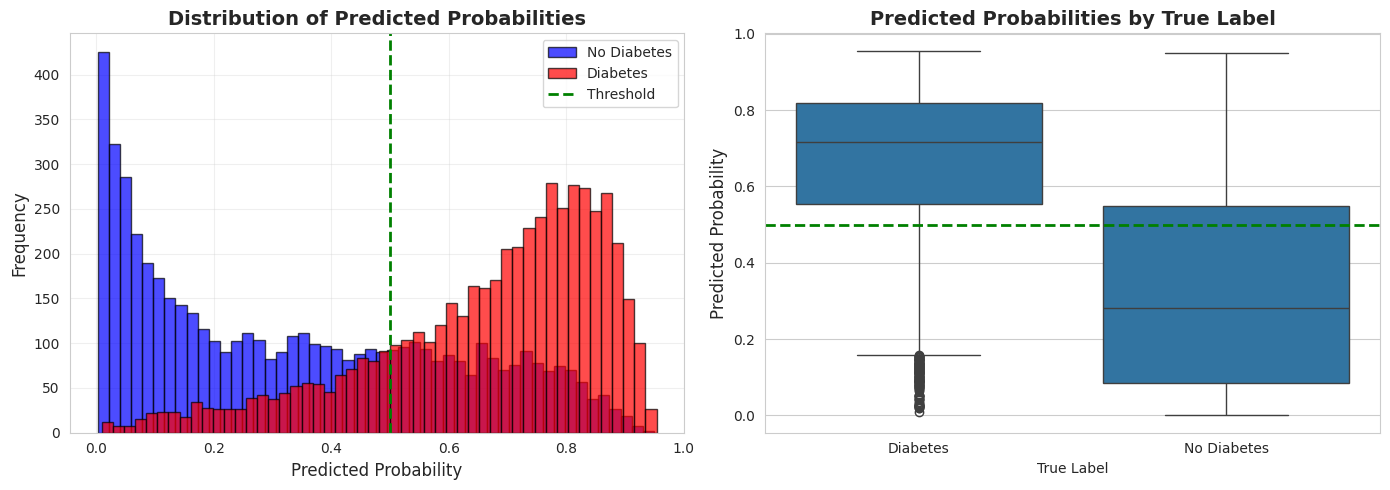

In [37]:
# 12. PREDICTION PROBABILITY DISTRIBUTION


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution for each class
axes[0].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7,
             label='No Diabetes', color='blue', edgecolor='black')
axes[0].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7,
             label='Diabetes', color='red', edgecolor='black')
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Predicted Probabilities',
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
prediction_df = pd.DataFrame({
    'Probability': y_pred_proba.flatten(),
    'True Label': ['No Diabetes' if label == 0 else 'Diabetes'
                   for label in y_test]
})
sns.boxplot(data=prediction_df, x='True Label', y='Probability', ax=axes[1])
axes[1].axhline(y=0.5, color='green', linestyle='--', linewidth=2)
axes[1].set_title('Predicted Probabilities by True Label',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Predicted Probability', fontsize=12)

plt.tight_layout()
plt.show()

In [38]:
# 13. SAVE RESULTS SUMMARY


results_summary = {
    'Model': 'Deep Neural Network (MLP)',
    'Architecture': '128-64-32 neurons',
    'Training Samples': X_train.shape[0],
    'Validation Samples': X_val.shape[0],
    'Test Samples': X_test.shape[0],
    'Number of Features': input_dim,
    'Test Accuracy': accuracy,
    'Test Precision': precision,
    'Test Recall': recall,
    'Test F1-Score': f1,
    'Test AUC-ROC': auc_roc,
    'Epochs Trained': len(history.history['loss']),
}

results_df = pd.DataFrame([results_summary])
print("\nModel Summary:")
print(results_df.T)

# Save to CSV
results_df.to_csv('model_results_summary.csv', index=False)
print("\nResults saved to 'model_results_summary.csv'")


Model Summary:
                                            0
Model               Deep Neural Network (MLP)
Architecture                128-64-32 neurons
Training Samples                        49512
Validation Samples                      10576
Test Samples                            10604
Number of Features                         21
Test Accuracy                        0.754338
Test Precision                       0.730473
Test Recall                          0.806111
Test F1-Score                        0.766431
Test AUC-ROC                         0.832288
Epochs Trained                             83

Results saved to 'model_results_summary.csv'


In [39]:
# 14. EXAMPLE PREDICTIONS


# Show a few example predictions
n_examples = 5
example_indices = np.random.choice(len(X_test), n_examples, replace=False)

print("\nExample Predictions:")
print("="*80)
for idx in example_indices:
    true_label = "Diabetes" if y_test.iloc[idx] == 1 else "No Diabetes"
    pred_proba = y_pred_proba[idx][0]
    pred_label = "Diabetes" if pred_proba > 0.5 else "No Diabetes"

    print(f"\nExample {idx}:")
    print(f"  True Label:      {true_label}")
    print(f"  Predicted Label: {pred_label}")
    print(f"  Probability:     {pred_proba:.4f}")
    print(f"  Correct:         {'✓' if true_label == pred_label else '✗'}")
print("="*80)


Example Predictions:

Example 4310:
  True Label:      No Diabetes
  Predicted Label: Diabetes
  Probability:     0.5504
  Correct:         ✗

Example 2643:
  True Label:      Diabetes
  Predicted Label: Diabetes
  Probability:     0.7192
  Correct:         ✓

Example 3663:
  True Label:      No Diabetes
  Predicted Label: Diabetes
  Probability:     0.7269
  Correct:         ✗

Example 164:
  True Label:      No Diabetes
  Predicted Label: No Diabetes
  Probability:     0.1900
  Correct:         ✓

Example 4995:
  True Label:      No Diabetes
  Predicted Label: No Diabetes
  Probability:     0.0220
  Correct:         ✓
